In [1]:
rm(list = ls())

library(data.table)
library(ggplot2)
library(scales)

# shared response palette (teal = responder, pink = non-responder)
resp_cols  <- c("Non-Responder" = "#d81463", "Responder" = "#00b2a8")
ylab_col   <- function(lvls, resp, subj) ifelse(resp[match(lvls, subj)] == "Responder",
                                              "#00b2a8", "#d81463")
out_dir    <- "../../data/figure-outputs/supplementary-7"

## 1 · Load & clean MSD flu data

In [2]:
### Load flu MSD panel + DIHA reference; drop technical replicates safely
fluDat <- fread('../../data/msd/FH1_FH2_BR2_Flu_MSD_NEW.csv')
diha   <- fread('../../data/msd/MSD_All_NEW.csv')
idx    <- grep('_a', fluDat$Subject)
if (length(idx)) fluDat <- fluDat[-idx]

### Restrict BR (healthy) samples to those used in the DIHA study
fh <- fluDat[grep('FH', Subject)];  fh[, sample_assay := paste(Sample, Assay)]
br <- fluDat[grep('BR', Subject)];  br[, sample_assay := paste(Sample, Assay)]
diha[, sample_assay := paste(Sample, Assay)]
fluDat <- rbind(fh, br[sample_assay %in% diha$sample_assay])

### Matched healthy donors from proteomics (BR1/BR2, Flu Y1D0)
plasma  <- readRDS('../../manuscript-figures/inputs/olink/MM_Plasma_Olink_Final.rds')
healthy <- plasma[plasma$cohort.cohortGuid %in% c('BR1','BR2')]
healthy <- healthy[sample.visitDetails == 'Flu_Y1D0']
matched_donors <- unique(healthy$subject.subjectGuid)

### Cohort labels, numeric value, vaccine year, tidy visit factor
fluDat[, Cohort := ""]
fluDat[grep('FH1', Subject), Cohort := 'FH1']
fluDat[grep('FH2', Subject), Cohort := 'FH2']
fluDat[grep('BR1', Subject), Cohort := 'Healthy']
fluDat[grep('BR2', Subject), Cohort := 'Healthy']
fluDat[, Flu_Season := gsub('flu season', '', Flu_Season)]
fluDat[, Year  := ifelse(grepl('Year 2', `Patient visit details`), 'Year 2', 'Year 1')]
fluDat[, Value := as.numeric(`Calc. Conc. Mean`)]
fluDat[, Visit := `Patient visit details`]
fluDat[, Visit := gsub('Flu Year 1','Y1', Visit)]
fluDat[, Visit := gsub('Flu Year 2','Y2', Visit)]
fluDat[, Visit := gsub('Stand-Alone','SA', Visit)]
fluDat[, Visit := factor(Visit, levels = c('Y1 SA','Y1 Day 0','Y1 Day 7','Y1 Day 90',
                                         'Y2 SA','Y2 Day 0','Y2 Day 7','Y2 Day 90'))]
fluDat[, sample_assay := paste(Subject, Visit, Assay)]

### Keep FH1 + matched healthy; drop non-VRD subjects; subset to Phuket/B
fluDat <- fluDat[, .(Subject, Value, Visit, Assay, Year, Flu_Season,
                   DaysSinceFirstVisit, Cohort, `Patient visit details`, sample_assay)]
fluDat <- rbind(fluDat[Cohort == 'FH1'],
              fluDat[Cohort != 'FH1' & Subject %in% matched_donors])
fluDat <- unique(fluDat)
fluDat <- fluDat[!Subject %in% c('FH1022','FH1024','FH1027')]

phuket     <- unique(fluDat[Assay == 'Flu B/Phuket HA'])   # one value per visit
phuket_fh1 <- phuket[Cohort == 'FH1']
phuket_fh1[, VaccineVisit := gsub('Y1 |Y2 ', '', Visit)]

## 2 · Figure G — CV-based stratification

In [3]:
### Analysis: CV per vaccine series (DO NOT reorder the season filter — see note)
CV_threshold <- 0.5
CV  <- phuket[Cohort == 'FH1',
            .(FluCV = sd(Value)/mean(Value), Flu_Season = Flu_Season),
            by = .(Subject, Year)]                 # FluCV recycled per row by design
FH1 <- unique(CV[Flu_Season != '#N/A'])              # drop series with no valid season
FH1[, FluCV_Combined := mean(FluCV), by = Subject]
FH1[, Responder := ifelse(FluCV_Combined > CV_threshold, 'Responder', 'Non-Responder')]

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


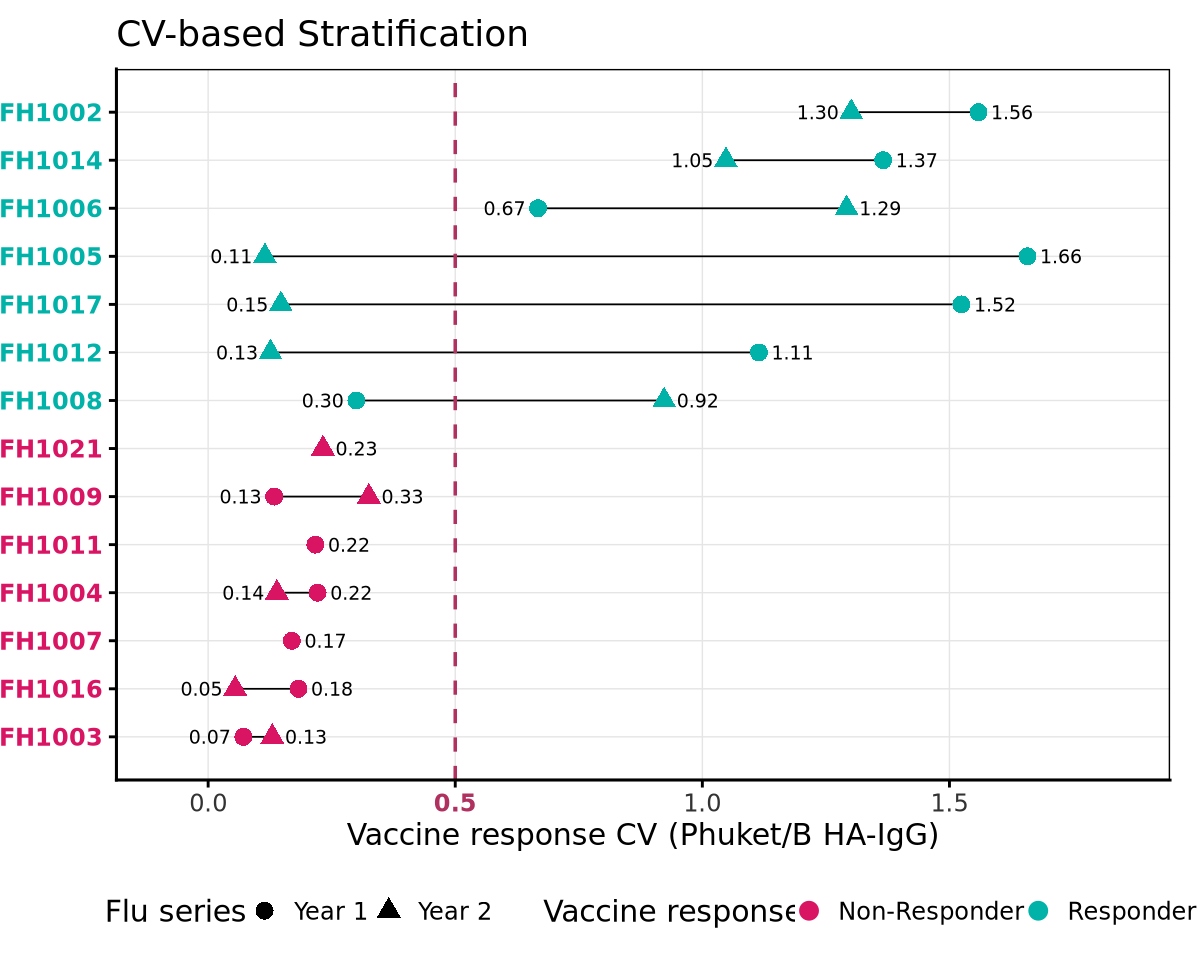

In [4]:
### Plot
options(repr.plot.width = 10, repr.plot.height = 8)
cv_year_df <- unique(FH1[, .(Subject, Year, FluCV, FluCV_Combined, Responder)])
ord <- unique(cv_year_df[order(FluCV_Combined), Subject])
cv_year_df[, Subject := factor(Subject, levels = ord)]
cv_year_df[, side := ifelse(frank(FluCV, ties.method="first") == 1 & .N > 1,
                          "left", "right"), by = Subject]
                          
g_ylab   <- ylab_col(levels(cv_year_df$Subject), cv_year_df$Responder, cv_year_df$Subject)
xb       <- c(0, 0.5, 1.0, 1.5)

p_g <- ggplot(cv_year_df, aes(x = FluCV, y = Subject)) +
geom_line(aes(group = Subject), colour = "black", linewidth = 0.5) +
geom_vline(xintercept = 0.5, linetype = 2, colour = "maroon", linewidth = 1) +
geom_point(aes(colour = Responder, shape = Year), size = 4.5) +
geom_text(aes(label = sprintf("%.2f", FluCV)), colour = "black", size = 4,
          hjust = ifelse(cv_year_df$side == "left", 1.3, -0.3)) +
scale_colour_manual(values = resp_cols) +
scale_shape_manual(values = c("Year 1" = 16, "Year 2" = 17)) +
scale_x_continuous(breaks = xb, expand = expansion(mult = c(0.15, 0.18))) +
scale_y_discrete(expand = expansion(add = 0.9)) +
labs(x = "Vaccine response CV (Phuket/B HA-IgG)", y = NULL,
     colour = "Vaccine response", shape = "Flu series", title = "CV-based Stratification") +
theme_classic(base_size = 18) +
theme(legend.position = "bottom",
      panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.8),
      axis.text.y  = element_text(colour = g_ylab, face = "bold"),
      axis.text.x  = element_text(colour = ifelse(xb == 0.5, "maroon", "grey20"),
                                  face   = ifelse(xb == 0.5, "bold", "plain")),
      plot.margin  = margin(12, 18, 12, 12),
      panel.grid.major = element_line(colour = "grey90", linewidth = 0.4))
p_g
ggsave(file.path(out_dir, "sup_7g.pdf"), p_g, width = 10, height = 8, dpi = 200, device = cairo_pdf)

## 3 · Figure H — Fold-change stratification

In [5]:
### Analysis: per-year fold change (single source of truth for H, I, and sensitivity)
fc_year_df <- phuket_fh1[,
.(baseline = max(Value[VaccineVisit %in% c('Day 0','SA')],   na.rm = TRUE),
  Peak     = max(Value[VaccineVisit %in% c('Day 7','Day 90')], na.rm = TRUE)),
by = .(Subject, Year)]
fc_year_df[, FC := Peak / baseline]
fc_year_df[, FC_max := max(FC), by = Subject]                     # peak FC across both series
fc_year_df[, Responder := ifelse(FC_max > 2, "Responder", "Non-Responder")]

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


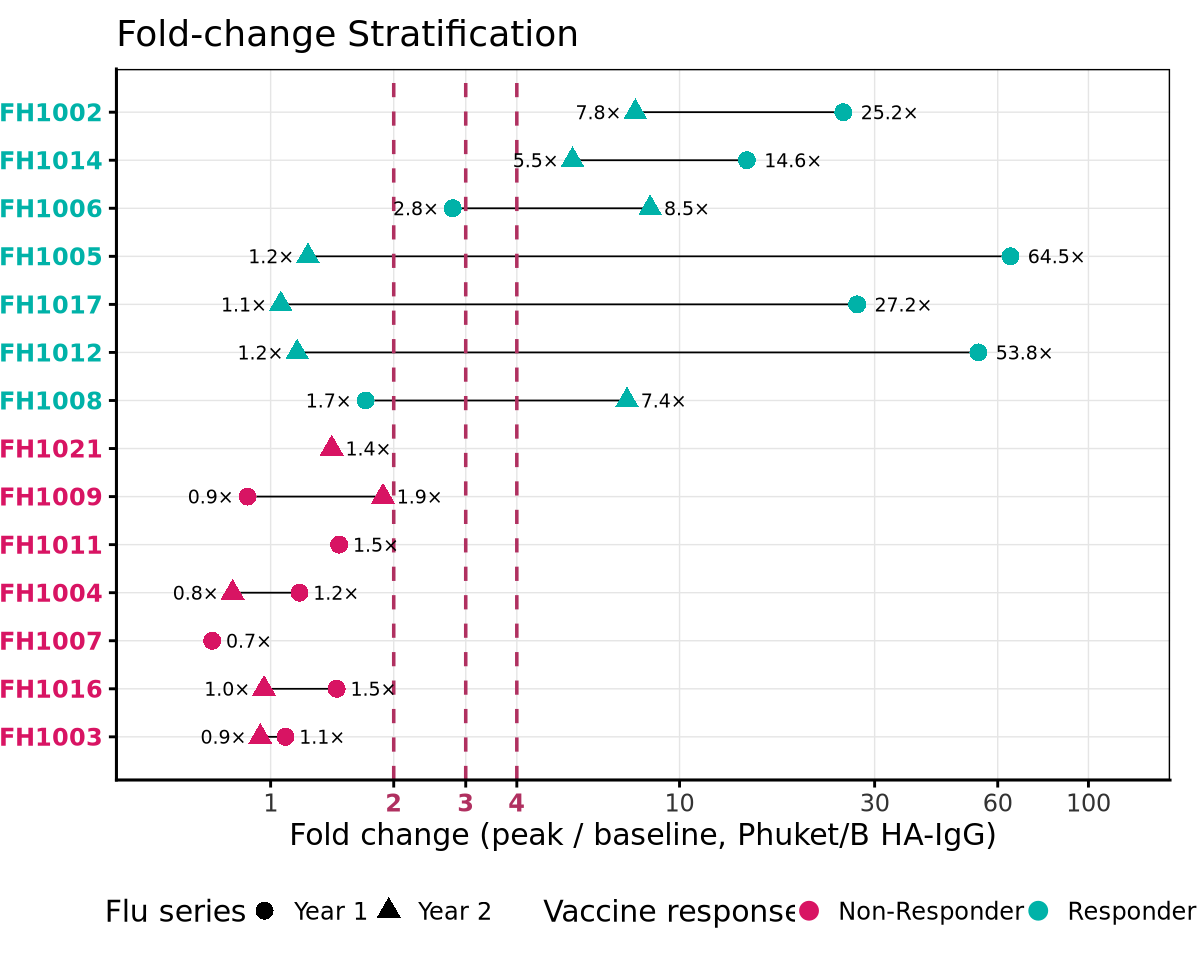

In [6]:
### Plot
options(repr.plot.width = 10, repr.plot.height = 8)
fc_year_df[, Subject := factor(Subject, levels = levels(cv_year_df$Subject))]
fc_year_df[, side := ifelse(frank(FC, ties.method="first") == 1 & .N > 1,
                          "left", "right"), by = Subject]

h_ylab <- ylab_col(levels(fc_year_df$Subject), fc_year_df$Responder, fc_year_df$Subject)
xb     <- c(1, 2, 3, 4, 10, 30, 60, 100)

p_h <- ggplot(fc_year_df, aes(x = FC, y = Subject)) +
geom_line(aes(group = Subject), colour = "black", linewidth = 0.5) +
geom_vline(xintercept = c(2, 3, 4), linetype = 2, colour = "maroon", linewidth = 1) +
geom_point(aes(colour = Responder, shape = Year), size = 4.5) +
geom_text(aes(label = sprintf("%.1f\u00d7", FC)), colour = "black", size = 4,
          hjust = ifelse(fc_year_df$side == "left", 1.3, -0.3)) +
scale_colour_manual(values = resp_cols) +
scale_shape_manual(values = c("Year 1" = 16, "Year 2" = 17)) +
scale_x_log10(breaks = xb, expand = expansion(mult = c(0.12, 0.20))) +
scale_y_discrete(expand = expansion(add = 0.9)) +
labs(x = "Fold change (peak / baseline, Phuket/B HA-IgG)", y = NULL,
     colour = "Vaccine response", shape = "Flu series", title = "Fold-change Stratification") +
theme_classic(base_size = 18) +
theme(legend.position = "bottom",
      panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.8),
      axis.text.y  = element_text(colour = h_ylab, face = "bold"),
      axis.text.x  = element_text(colour = ifelse(xb %in% c(2,3,4), "maroon", "grey20"),
                                  face   = ifelse(xb %in% c(2,3,4), "bold", "plain")),
      plot.margin  = margin(12, 18, 12, 12),
      panel.grid.major = element_line(colour = "grey90", linewidth = 0.4))
p_h
ggsave(file.path(out_dir, "sup_7h.pdf"), p_h, width = 10, height = 8, dpi = 200, device = cairo_pdf)

## 4 · Figure I — Baseline vs peak IgG

In [7]:
### Analysis: each subject's strongest-responding series
fc_best <- fc_year_df[fc_year_df[, .I[which.max(FC)], by = Subject]$V1]
fc_best <- fc_best[, .(subject = as.character(Subject), baseline, peak = Peak,
                     fc = FC, Responder)][order(peak)]
fc_best[, subject := factor(subject, levels = subject)]            # order by peak IgG

df_long <- melt(fc_best, id.vars = c("subject","fc","Responder"),
              measure.vars = c("baseline","peak"),
              variable.name = "stage", value.name = "value")
df_long[, pt_group := factor(ifelse(stage == "baseline", "Baseline", as.character(Responder)),
                           levels = c("Baseline","Responder","Non-Responder"))]

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


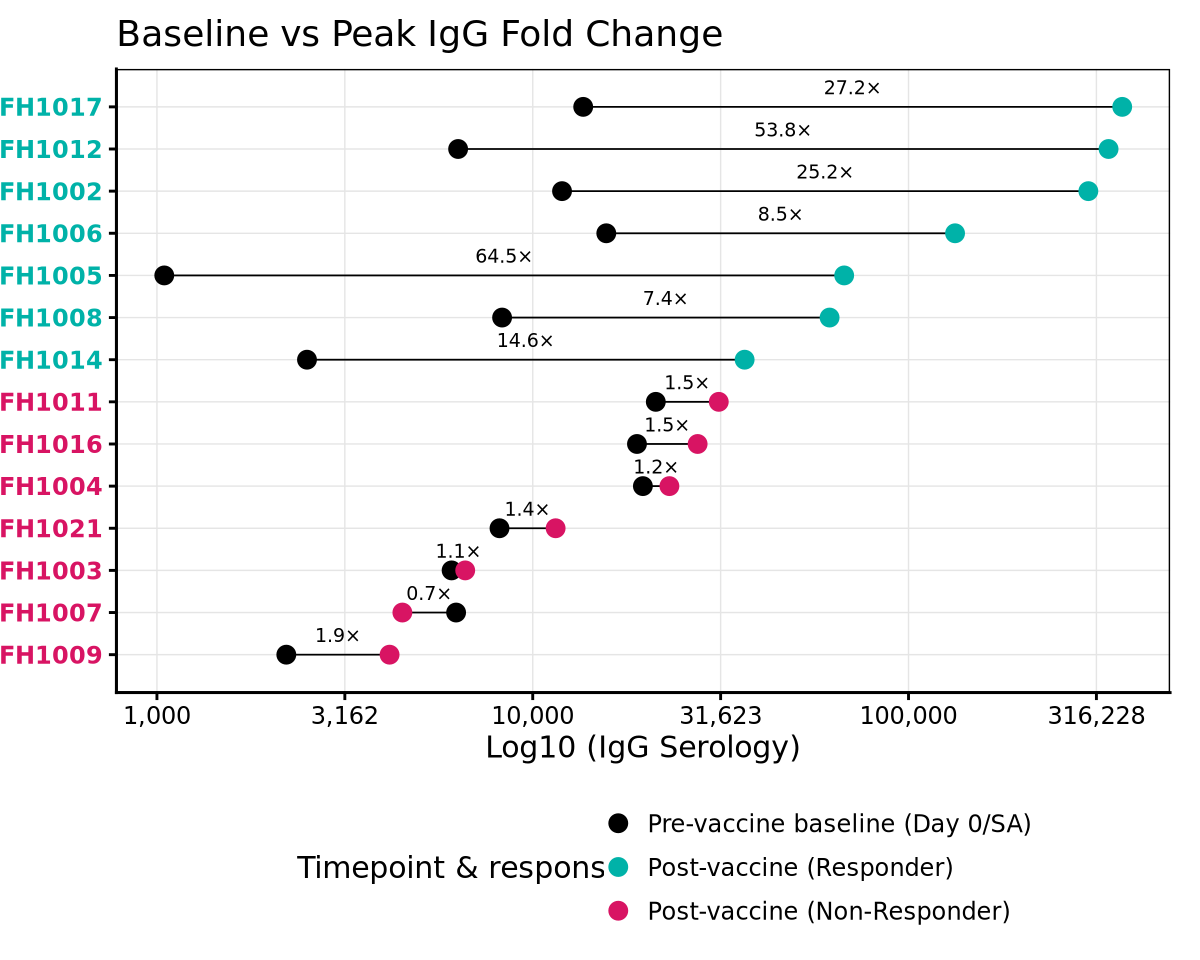

In [8]:
### Plot
options(repr.plot.width = 10, repr.plot.height = 8)
i_ylab <- ylab_col(levels(fc_best$subject), fc_best$Responder, fc_best$subject)

p_i <- ggplot(fc_best) +
geom_segment(aes(x = baseline, xend = peak, y = subject, yend = subject),
             linewidth = 0.5, colour = "black") +
geom_point(data = df_long, aes(x = value, y = subject, colour = pt_group), size = 4.5) +
geom_text(aes(x = sqrt(baseline * peak), y = subject, label = sprintf("%.1f\u00d7", fc)),
          vjust = -0.9, size = 4, colour = "black") +              # geom mean = log midpoint
scale_colour_manual(
  values = c("Baseline" = "black", "Responder" = "#00b2a8", "Non-Responder" = "#d81463"),
  labels = c("Baseline" = "Pre-vaccine baseline (Day 0/SA)",
             "Responder" = "Post-vaccine (Responder)",
             "Non-Responder" = "Post-vaccine (Non-Responder)")) +
scale_x_log10(labels = label_comma(), breaks = trans_breaks("log10", function(x) 10^x)) +
scale_y_discrete(expand = expansion(add = 0.9)) +
guides(colour = guide_legend(ncol = 1)) +
labs(x = "Log10 (IgG Serology)", y = NULL, colour = "Timepoint & response",
     title = "Baseline vs Peak IgG Fold Change") +
theme_classic(base_size = 18) +
theme(legend.position = "bottom",
      panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.8),
      axis.text.y  = element_text(colour = i_ylab, face = "bold"),
      plot.margin  = margin(12, 18, 12, 12),
      panel.grid.major = element_line(colour = "grey90", linewidth = 0.4))
p_i
ggsave(file.path(out_dir, "sup_7i.pdf"), p_i, width = 10, height = 8, dpi = 200, device = cairo_pdf)

  ## 5 · Metric concordance & sensitivity (Supp Table 1P)

In [9]:
### Per-subject max FC -> threshold sensitivity (FIXED: was counting 25 year-rows)
fc_subj <- unique(fc_year_df[, .(Subject, FC = FC_max, Responder)])
sensitivity <- rbindlist(lapply(c(2,3,4), function(x)
data.table(threshold = x,
           responder     = sum(fc_subj$FC >= x),
           non_responder = sum(fc_subj$FC <  x))))
print(sensitivity)                                   # now 7 / 7 at every threshold

### CV vs FC agreement per subject
final_result <- merge(unique(FH1[, .(Subject, FluCV_Combined, Responder)]),
                    fc_subj[, .(Subject, FC)], by = "Subject")
for (thr in c(2, 3, 4)) {
cat("\nCV responder vs FC >", thr, "\n"); print(table(final_result$Responder, final_result$FC > thr))
}

fwrite(final_result, file.path(out_dir, "vaccine_stratification_metrics.csv"))

   threshold responder non_responder
       <num>     <int>         <int>
1:         2         7             7
2:         3         7             7
3:         4         7             7

CV responder vs FC > 2 
               
                FALSE TRUE
  Non-Responder     7    0
  Responder         0    7

CV responder vs FC > 3 
               
                FALSE TRUE
  Non-Responder     7    0
  Responder         0    7

CV responder vs FC > 4 
               
                FALSE TRUE
  Non-Responder     7    0
  Responder         0    7
